In [1]:
import os

GPU_NUM = 0
GPU_NUM = str(GPU_NUM)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" 
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_NUM 

# torch를 CUDA_VISIBLE_DEVICES 뒤에 import 해야 제대로 설정됨.
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f'CUDA Device Name: {torch.cuda.get_device_name(0)}, GPU NUM: {GPU_NUM}')
else: print(device)

torch.cuda.empty_cache() 

CUDA Device Name: NVIDIA GeForce RTX 3090, GPU NUM: 0


In [2]:
from dataclasses import dataclass

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

In [3]:
from utils.utils import *
from utils.config import Config

# allocate_dummy_gpu_memory(10)

In [4]:
cfg = Config(name='Dataset_Haze_Clutter', data='EchoNet-Dynamic')
print(cfg)

NOISY_DIR = Path(cfg.data_path) / cfg.data / 'sub_speckle' / 'noisy'
NOISE_DIR = Path(cfg.data_path) / cfg.data / 'sub_speckle' / 'noise'
CLEAN_DIR = Path(cfg.data_path) / cfg.data / 'sub_speckle' / 'clean'
MASK_DIR  = Path(cfg.data_path) / cfg.data / 'sub_speckle' / 'mask'


SAVE_DIR = Path(cfg.data_path) / f'{cfg.data}'

# print(f'ECHO_DIR: {ECHO_DIR}')
print(f'SAVE_DIR: {SAVE_DIR}')

----------------------------------------------------------------------
                        Config Details (Auto)                         
----------------------------------------------------------------------

[ Base Settings ]
  name                   : Dataset_Haze_Clutter
  data                   : EchoNet-Dynamic
  mkdir                  : False
  dtype                  : float64
  device                 : cpu
  multi_gpu              : False

[ Paths ]
  base_path              : /ds/mkseo/SM-Dehazing
  data_path              : /ds/mkseo/SM-Dehazing/data
  res_path               : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter
  fig_path               : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter/fig
  loss_path              : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter/loss
  model_path             : /ds/mkseo/SM-Dehazing/res/Dataset_Haze_Clutter/model
----------------------------------------------------------------------
SAVE_DIR: /ds/mkseo/SM-Dehazing/data/EchoNet-Dyna

In [5]:
import tifffile as tiff

noisy_imgs = listdir(NOISY_DIR)
noise_imgs = listdir(NOISE_DIR)
clean_imgs = listdir(CLEAN_DIR)

noisy = tiff.imread(NOISY_DIR / noisy_imgs[0])
noise = tiff.imread(NOISE_DIR / noise_imgs[0])
clean = tiff.imread(CLEAN_DIR / clean_imgs[0])

print(noisy.shape, noise.shape, clean.shape)
print(clean.min(), clean.max())
print(noise.min(), noise.max())
print(noisy.min(), noisy.max())

(112, 112) (112, 112) (112, 112)
0.0 1.0
0.3780539 1.760383
0.0 1.0


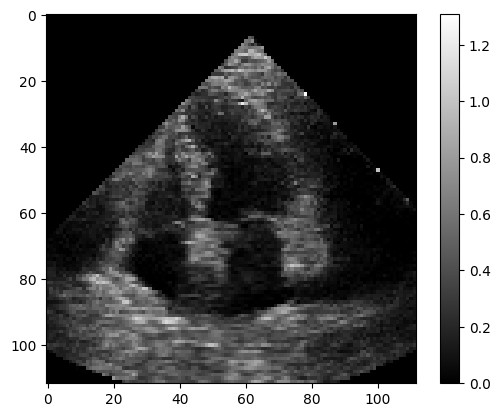

In [6]:
weighted_noise = clean * noise

plt.imshow(weighted_noise, cmap='gray')
plt.colorbar()

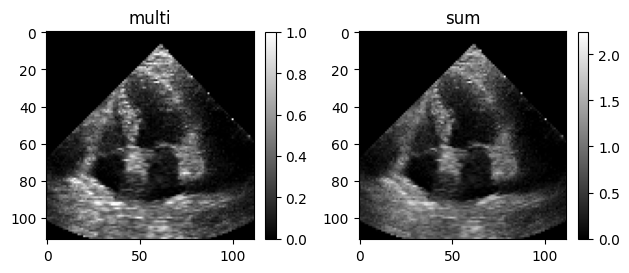

In [7]:
sumed_noisy = clean + weighted_noise

imgs = [noisy, sumed_noisy]
titles = ['multi', 'sum']

for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(titles[i])
    plt.colorbar(fraction=0.045)

plt.tight_layout()
plt.show()

In [ ]:
Sumation_Speckle_Noisy_DIR  = SAVE_DIR / 'sumation_speckle' / 'noisy'
Sumation_Speckle_Noise_DIR  = SAVE_DIR / 'sumation_speckle' / 'noise'
Sumation_Weighted_Noise_DIR = SAVE_DIR / 'sumation_speckle' / 'sumation_noise'
Sumation_Speckle_Clean_DIR  = SAVE_DIR / 'sumation_speckle' / 'clean'

mk_dir([Sumation_Speckle_Clean_DIR, Sumation_Speckle_Noise_DIR, 
        Sumation_Speckle_Noisy_DIR, Sumation_Weighted_Noise_DIR])

pid_list = listdir(CLEAN_DIR)
pbar = tqdm(pid_list)
for pid in pbar:
    clean = tiff.imread(CLEAN_DIR / pid)
    noise = tiff.imread(NOISE_DIR / pid)
    mask  = cv2.imread(MASK_DIR / f'{pid.split('.')[0]}.png', 0)

    pbar.set_description(f"Processing {pid}")

    weighted_noise = clean * noise
    sumed_noisy = clean + weighted_noise

    clean_f32   = clean.astype(np.float32)
    noisy_f32   = sumed_noisy.astype(np.float32)
    sum_noise   = weighted_noise.astype(np.float32)
    noise_f32   = noise.astype(np.float32)

    cv2.imwrite(str(Sumation_Speckle_Clean_DIR / pid), clean_f32)
    cv2.imwrite(str(Sumation_Speckle_Noisy_DIR / pid), noisy_f32)
    cv2.imwrite(str(Sumation_Weighted_Noise_DIR / pid), sum_noise)
    cv2.imwrite(str(Sumation_Speckle_Noise_DIR / pid), noise_f32)

Processing Patient_00001_F001.tiff:   0%|          | 0/3072 [00:00<?, ?it/s]

Processing Patient_10030_F003.tiff: 100%|██████████| 3072/3072 [06:07<00:00,  8.36it/s]
